# Movie Dataset — EDA & Preprocessing

This notebook explores the raw movie dataset, identifies data quality issues,
and applies the preprocessing steps needed before generating embeddings.

In [30]:
# standard data science stack
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# make plots look clean
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

## 1 · Load the raw data

In [31]:
# read the CSV that ships with the repo
df_raw = pd.read_csv("../data/raw/movies.csv")
print(f"Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
df_raw.head()

Shape: 10,178 rows × 12 columns


,names,date_x,score,genre,overview,crew,orig_title,status,orig_lang,budget_x,revenue,country
0,Creed III,03/02/2023,73.0,"Drama, Action","After dominating the boxing world, Adonis Cree...","Michael B. Jordan, Adonis Creed, Tessa Thompso...",Creed III,Released,English,75000000.0,2.716167e+08,AU
1,Avatar: The Way of Water,12/15/2022,78.0,"Science Fiction, Adventure, Action",Set more than a decade after the events of the...,"Sam Worthington, Jake Sully, Zoe Saldaña, Neyt...",Avatar: The Way of Water,Released,English,460000000.0,2.316795e+09,AU
2,The Super Mario Bros. Movie,04/05/2023,76.0,"Animation, Adventure, Family, Fantasy, Comedy","While working underground to fix a water main,...","Chris Pratt, Mario (voice), Anya Taylor-Joy, P...",The Super Mario Bros. Movie,Released,English,100000000.0,7.244590e+08,AU
3,Mummies,01/05/2023,70.0,"Animation, Comedy, Family, Adventure, Fantasy","Through a series of unfortunate events, three ...","Óscar Barberán, Thut (voice), Ana Esther Albor...",Momias,Released,"Spanish, Castilian",12300000.0,3.420000e+07,AU
4,Supercell,03/17/2023,61.0,Action,Good-hearted teenager William always lived in ...,"Skeet Ulrich, Roy Cameron, Anne Heche, Dr Quin...",Supercell,Released,English,77000000.0,3.409420e+08,US


## 2 · Quick schema overview

In [32]:
# data types and non-null counts
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 10178 entries, 0 to 10177
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   names       10178 non-null  str    
 1   date_x      10178 non-null  str    
 2   score       10178 non-null  float64
 3   genre       10093 non-null  str    
 4   overview    10178 non-null  str    
 5   crew        10122 non-null  str    
 6   orig_title  10178 non-null  str    
 7   status      10178 non-null  str    
 8   orig_lang   10178 non-null  str    
 9   budget_x    10178 non-null  float64
 10  revenue     10178 non-null  float64
 11  country     10178 non-null  str    
dtypes: float64(3), str(9)
memory usage: 954.3 KB


In [33]:
# basic stats for numeric columns
df_raw.describe()

,score,budget_x,revenue
count,10178.000000,1.017800e+04,1.017800e+04
mean,63.497052,6.488238e+07,2.531401e+08
std,13.537012,5.707565e+07,2.777880e+08
min,0.000000,1.000000e+00,0.000000e+00
25%,59.000000,1.500000e+07,2.858898e+07
50%,65.000000,5.000000e+07,1.529349e+08
75%,71.000000,1.050000e+08,4.178021e+08
max,100.000000,4.600000e+08,2.923706e+09


## 3 · Missing values

In [34]:
# count and percentage of nulls per column
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct}).sort_values("missing_pct", ascending=False)

,missing_count,missing_pct
genre,85,0.84
crew,56,0.55
date_x,0,0.00
names,0,0.00
score,0,0.00
overview,0,0.00
orig_title,0,0.00
status,0,0.00
orig_lang,0,0.00
budget_x,0,0.00


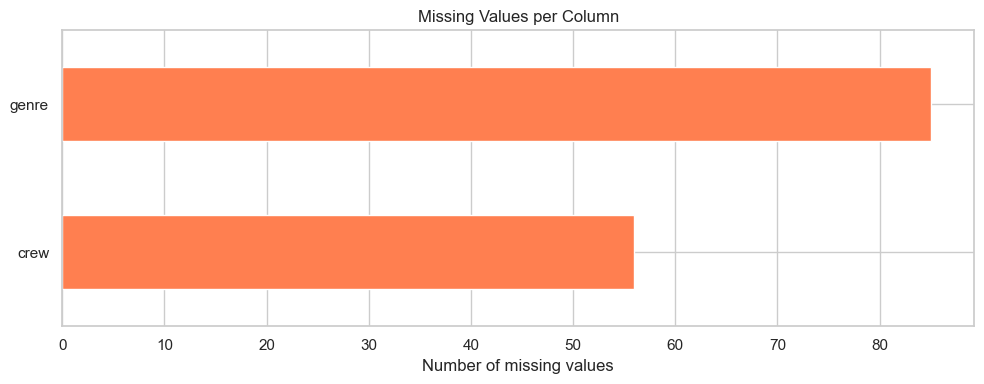

In [35]:
# visualize missingness
fig, ax = plt.subplots(figsize=(10, 4))
missing[missing > 0].sort_values().plot.barh(ax=ax, color="coral")
ax.set_xlabel("Number of missing values")
ax.set_title("Missing Values per Column")
plt.tight_layout()
plt.show()

## 4 · Duplicate analysis

In [36]:
# check for exact row duplicates
exact_dupes = df_raw.duplicated().sum()
print(f"Exact duplicate rows: {exact_dupes}")

# check for same-title-same-date duplicates (the meaningful definition)
title_date_dupes = df_raw.duplicated(subset=["names", "date_x"]).sum()
print(f"Same (title + date) duplicates: {title_date_dupes}")

Exact duplicate rows: 0
Same (title + date) duplicates: 179


In [37]:
# peek at a few duplicate groups
dupe_mask = df_raw.duplicated(subset=["names", "date_x"], keep=False)
if dupe_mask.any():
    sample_name = df_raw.loc[dupe_mask, "names"].iloc[0]
    display(df_raw[df_raw["names"] == sample_name])

,names,date_x,score,genre,overview,crew,orig_title,status,orig_lang,budget_x,revenue,country
95,Scream,01/13/2022,67.0,"Horror, Mystery, Thriller",Twenty-five years after a streak of brutal mur...,"Melissa Barrera, Sam Carpenter, Mason Gooding,...",Scream,Released,English,24000000.0,138874789.0,AU
96,Scream,01/13/2022,67.0,"Horror, Mystery, Thriller",Twenty-five years after a streak of brutal mur...,"Melissa Barrera, Sam Carpenter, Mason Gooding,...",Scream,Released,English,15000000.0,173046640.0,AU
379,Scream,02/13/1997,74.0,"Crime, Horror, Mystery",After a series of mysterious deaths befalls th...,"David Arquette, Dewey Riley, Neve Campbell, Si...",Scream,Released,English,24000000.0,138874789.0,AU
380,Scream,02/13/1997,74.0,"Crime, Horror, Mystery",After a series of mysterious deaths befalls th...,"David Arquette, Dewey Riley, Neve Campbell, Si...",Scream,Released,English,15000000.0,173046640.0,AU
6502,Scream,01/08/1981,41.0,"Horror, Mystery",A group of friends on a rafting trip down a ri...,"Pepper Martin, Bob, Hank Worden, John, Ethan W...",Scream,Released,English,24000000.0,138874789.0,US
6503,Scream,01/08/1981,41.0,"Horror, Mystery",A group of friends on a rafting trip down a ri...,"Pepper Martin, Bob, Hank Worden, John, Ethan W...",Scream,Released,English,15000000.0,173046640.0,US


## 5 · Score distribution

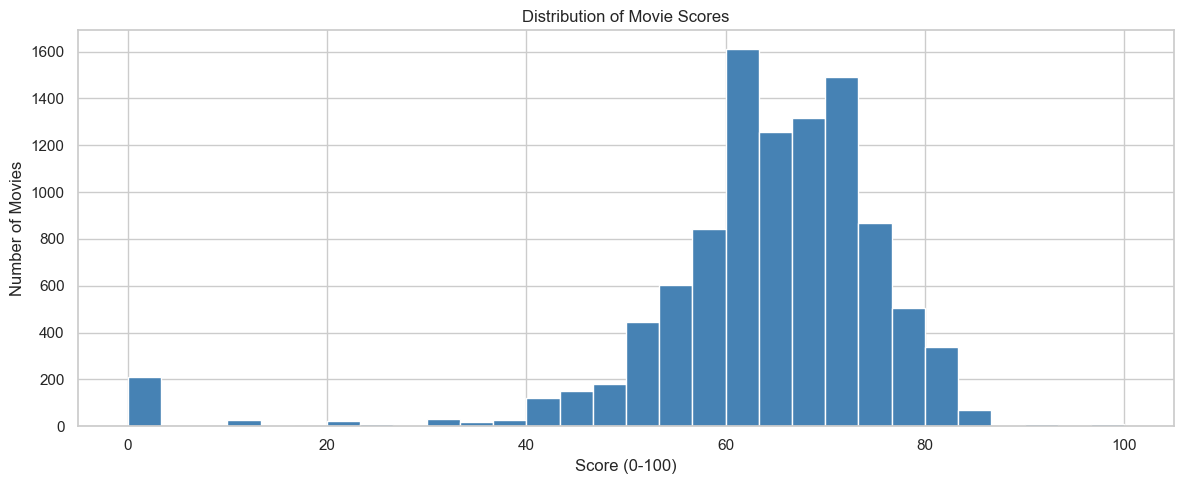

In [38]:
# histogram of review scores
fig, ax = plt.subplots()
df_raw["score"].dropna().hist(bins=30, ax=ax, color="steelblue", edgecolor="white")
ax.set_xlabel("Score (0-100)")
ax.set_ylabel("Number of Movies")
ax.set_title("Distribution of Movie Scores")
plt.tight_layout()
plt.show()

## 6 · Genre breakdown

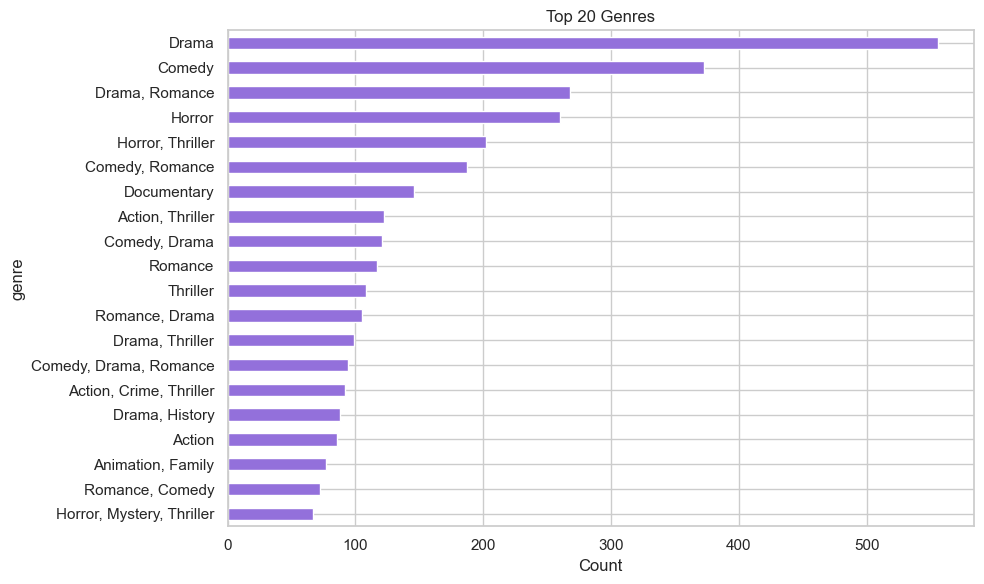

In [39]:
# each row may have comma-separated genres — split and count
all_genres = df_raw["genre"].dropna().str.split(", ").explode()
top_genres = all_genres.value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 6))
top_genres.sort_values().plot.barh(ax=ax, color="mediumpurple")
ax.set_xlabel("Count")
ax.set_title("Top 20 Genres")
plt.tight_layout()
plt.show()

## 7 · Release date & year trends

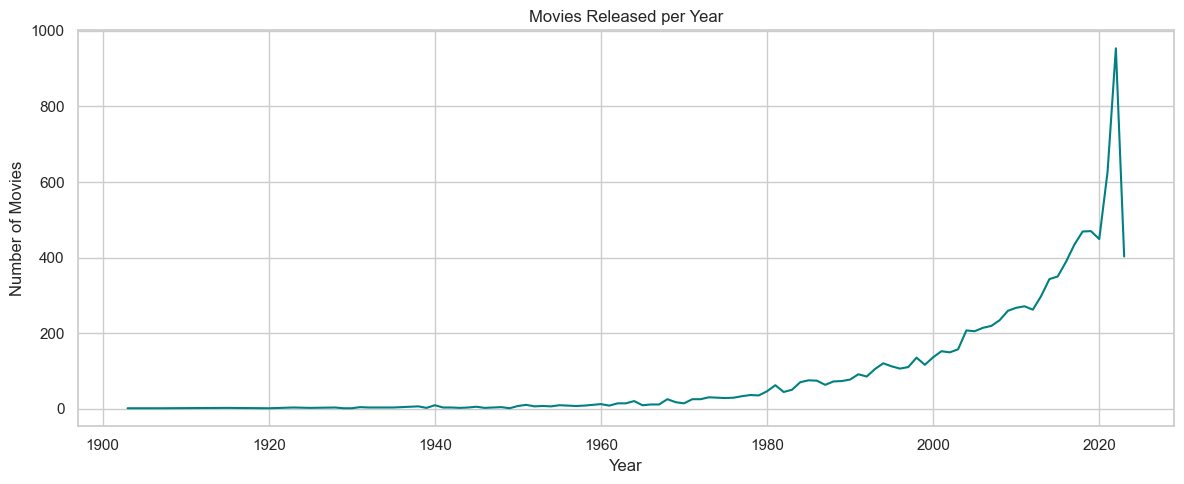

In [40]:
# extract year from the date string (format: MM/DD/YYYY)
df_raw["year"] = df_raw["date_x"].str.strip().str.split("/").str[-1].astype(float)

fig, ax = plt.subplots()
df_raw["year"].dropna().astype(int).value_counts().sort_index().plot(ax=ax, color="teal")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Movies")
ax.set_title("Movies Released per Year")
plt.tight_layout()
plt.show()

## 8 · Budget & revenue

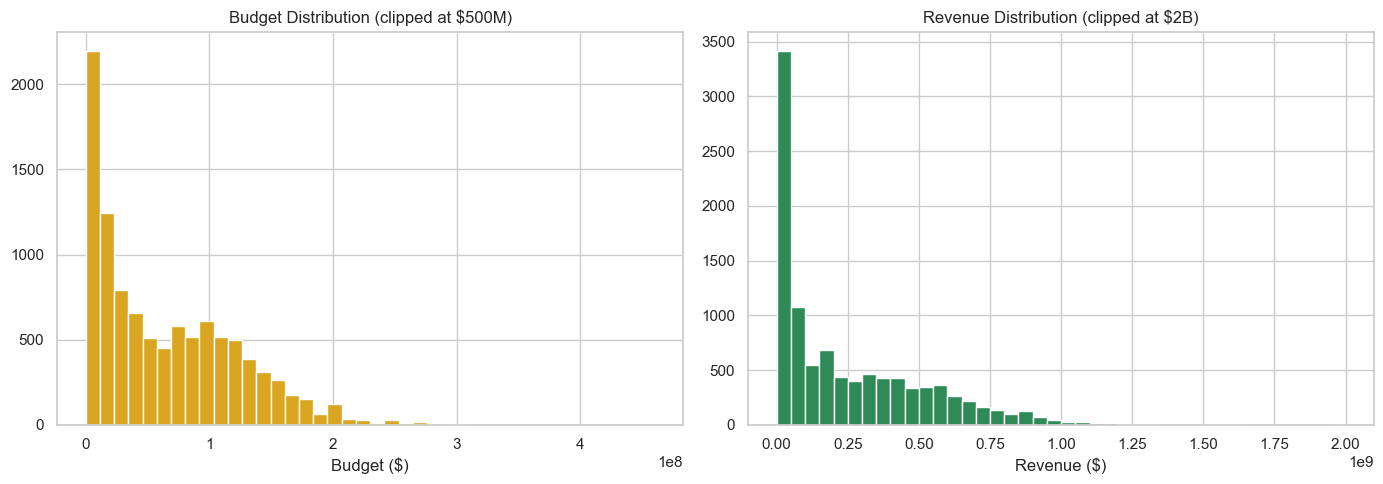

In [41]:
# quick look at financial columns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_raw["budget_x"].dropna().clip(upper=5e8).hist(bins=40, ax=axes[0], color="goldenrod", edgecolor="white")
axes[0].set_title("Budget Distribution (clipped at $500M)")
axes[0].set_xlabel("Budget ($)")

df_raw["revenue"].dropna().clip(upper=2e9).hist(bins=40, ax=axes[1], color="seagreen", edgecolor="white")
axes[1].set_title("Revenue Distribution (clipped at $2B)")
axes[1].set_xlabel("Revenue ($)")

plt.tight_layout()
plt.show()

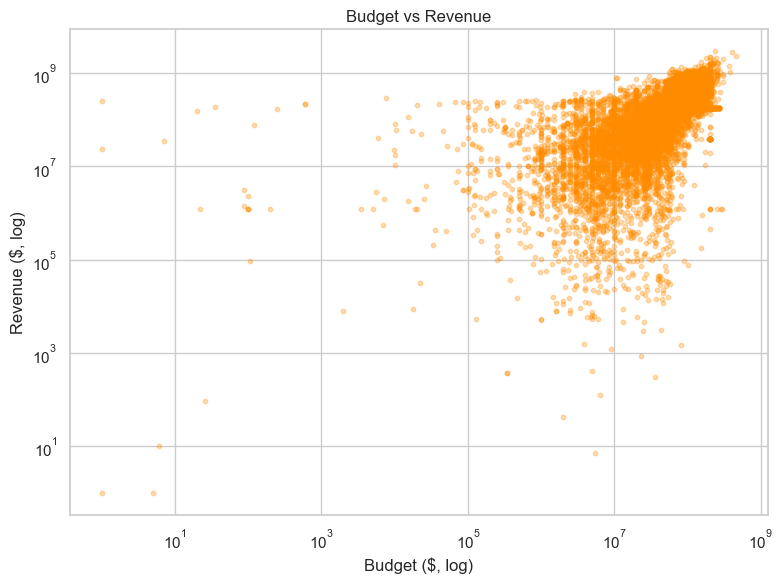

In [42]:
# scatter: budget vs revenue (log scale)
fig, ax = plt.subplots(figsize=(8, 6))
mask = (df_raw["budget_x"] > 0) & (df_raw["revenue"] > 0)
ax.scatter(df_raw.loc[mask, "budget_x"], df_raw.loc[mask, "revenue"],
           alpha=0.3, s=10, color="darkorange")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Budget ($, log)")
ax.set_ylabel("Revenue ($, log)")
ax.set_title("Budget vs Revenue")
plt.tight_layout()
plt.show()

## 9 · Language & country

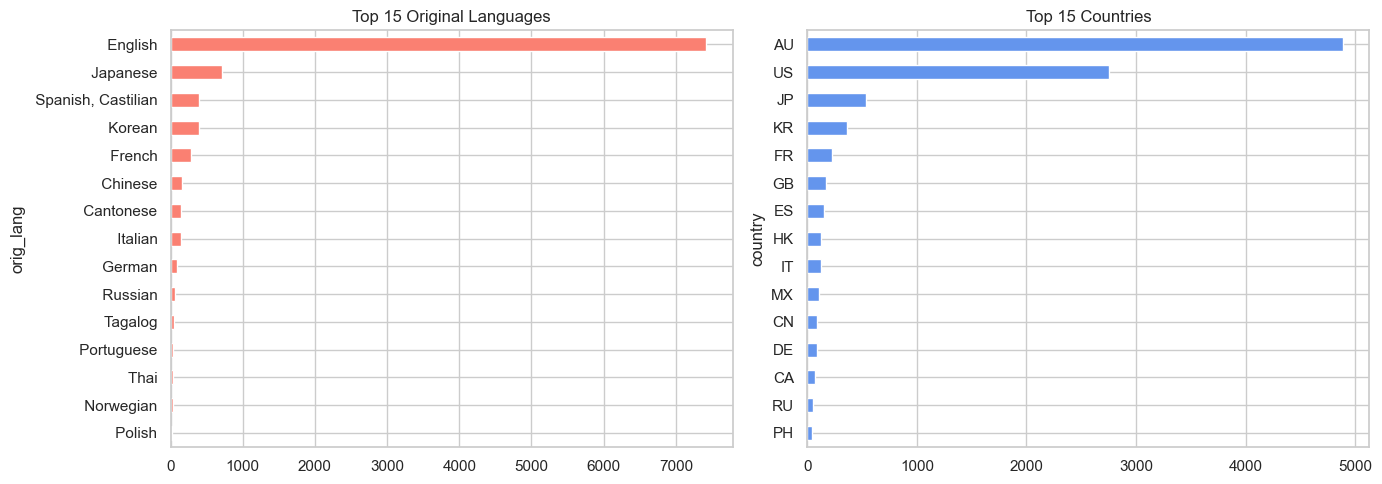

In [43]:
# top 15 original languages
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_raw["orig_lang"].value_counts().head(15).sort_values().plot.barh(ax=axes[0], color="salmon")
axes[0].set_title("Top 15 Original Languages")

df_raw["country"].value_counts().head(15).sort_values().plot.barh(ax=axes[1], color="cornflowerblue")
axes[1].set_title("Top 15 Countries")

plt.tight_layout()
plt.show()

## 10 · Overview text length

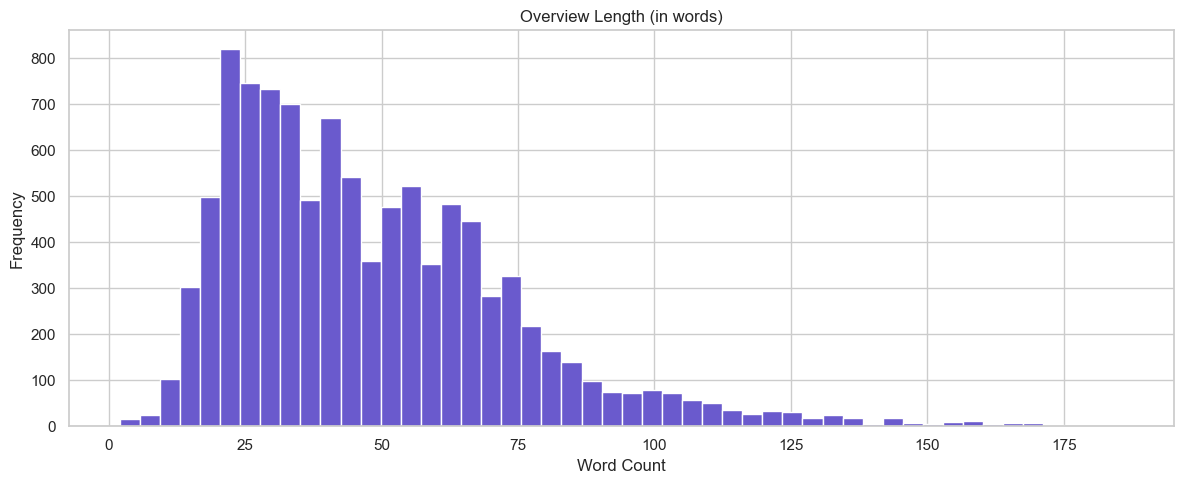

Median overview length: 42 words
Max overview length:    186 words


In [44]:
# word count of the overview field
df_raw["overview_len"] = df_raw["overview"].fillna("").apply(lambda x: len(x.split()))

fig, ax = plt.subplots()
df_raw["overview_len"].hist(bins=50, ax=ax, color="slateblue", edgecolor="white")
ax.set_xlabel("Word Count")
ax.set_ylabel("Frequency")
ax.set_title("Overview Length (in words)")
plt.tight_layout()
plt.show()

print(f"Median overview length: {df_raw['overview_len'].median():.0f} words")
print(f"Max overview length:    {df_raw['overview_len'].max()} words")

## 11 · Correlation heatmap (numeric columns)

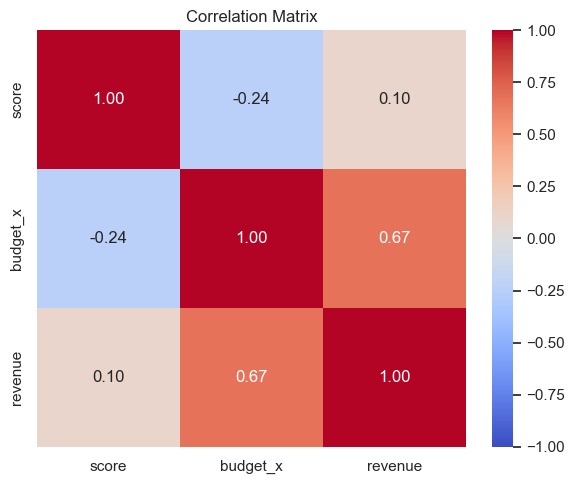

In [45]:
# correlations between numeric features
numeric_cols = ["score", "budget_x", "revenue"]
corr = df_raw[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", ax=ax, vmin=-1, vmax=1)
ax.set_title("Correlation Matrix")
plt.tight_layout()
plt.show()

---
# 🧹 Preprocessing Pipeline

The steps below clean the data and prepare it for embedding generation.

## 12 · Remove placeholder overviews

In [46]:
# some movies have a generic placeholder instead of a real overview — drop them
placeholder = "We don't have an overview translated in English. Help us expand our database by adding one."
df = df_raw[df_raw["overview"] != placeholder].copy()
print(f"Dropped {len(df_raw) - len(df):,} placeholder rows  →  {len(df):,} remaining")

Dropped 89 placeholder rows  →  10,089 remaining


## 13 · Fill missing genres and cast/crew

In [47]:
# fill missing genre with "Unknown" so downstream code doesn't break
df["genre"] = df["genre"].fillna("Unknown")
df["crew"] = df["crew"].fillna("Unknown")
print("Null in genre:", df["genre"].isnull().sum())
print("Null in crew:", df["crew"].isnull().sum())

Null in genre: 0
Null in crew: 0


## 14 · De-duplicate by (title, date)

In [48]:
# some movies appear more than once — aggregate them into a single row
before = len(df)
df = df.groupby(["names", "date_x"]).agg({
    "score": "mean",          # average scores
    "genre": "first",         # keep first genre string
    "overview": "first",      # keep first overview
    "crew": "first",          # keep first crew info
    "orig_title": "first",    # keep original title
    "status": "first",        # keep first status
    "orig_lang": "first",     # keep original language
    "budget_x": "sum",        # sum budgets
    "revenue": "sum",         # sum revenues
    "country": "first"        # keep first country
}).reset_index()

print(f"De-duplication: {before:,}  →  {len(df):,} rows")

De-duplication: 10,089  →  9,910 rows


## 15 · Build the text representation

In [49]:
# combine all fields into a single string that the embedding model will encode
def textify_movie(row):
    def clean(val):
        if pd.isna(val) or val == "":
            return "Unknown"
        return str(val)

    name     = clean(row.get("names"))
    date     = clean(row.get("date_x"))
    score    = clean(row.get("score"))
    genres   = clean(row.get("genre"))
    overview = clean(row.get("overview"))
    crew     = clean(row.get("crew"))
    lang     = clean(row.get("orig_lang"))
    budget   = clean(row.get("budget_x"))
    rev      = clean(row.get("revenue"))
    country  = clean(row.get("country"))

    text  = f"Title: {name}. Released in {date}, this {country} film is primarily in {lang}. "
    text += f"It falls under the {genres} genre. "
    text += f"It holds a rating of {score}/100. "
    text += f"Financially, it had a budget of ${budget} and made ${rev} in revenue. "
    text += f"Plot overview: {overview} "
    text += f"Key crew members include: {crew}."
    return text

df["content"] = df.apply(textify_movie, axis=1)
print("Sample content string:")
print(df["content"].iloc[0][:300], "...")

Sample content string:
Title: #Alive. Released in 06/24/2020 , this KR film is primarily in  Korean. It falls under the Horror, Action, Adventure, Thriller genre. It holds a rating of 73.0/100. Financially, it had a budget of $6300000.0 and made $13416285.0 in revenue. Plot overview: As a grisly virus rampages a city, a l ...


## 16 · Verify the cleaned dataset

In [50]:
# final sanity checks
print(f"Final shape: {df.shape}")
print(f"Null check:\n{df.isnull().sum()}")
print(f"\nColumns: {list(df.columns)}")

Final shape: (9910, 13)
Null check:
names         0
date_x        0
score         0
genre         0
overview      0
crew          0
orig_title    0
status        0
orig_lang     0
budget_x      0
revenue       0
country       0
content       0
dtype: int64

Columns: ['names', 'date_x', 'score', 'genre', 'overview', 'crew', 'orig_title', 'status', 'orig_lang', 'budget_x', 'revenue', 'country', 'content']


## 17 · Export (optional)

The cleaned dataframe is now ready for the embedding pipeline in `notebook.ipynb`.
Un-comment the cell below to save a CSV snapshot.

In [ ]:
# df.to_csv("../data/processed/cleaned_for_embeddings.csv", index=False)
# print("Saved!")

Saved!
